# 11 — Biologically-Constrained Video Model via FGW

Train a simple two-layer video model on the optical-flow stimuli used to record biological neural data.
Two internal layers are constrained via Fused Gromov-Wasserstein (FGW) to match the manifold structure
of retina and V1 responses respectively.

**Task**: 8-way direction classification (0°, 45°, …, 315°)  
**Train/val split**: by stimulus category (val = held-out non-biological categories)  
**FGW tuning features**: direction tuning vectors (8-dim, per neuron), which subsume OSI/DSI information  
**Models**: (1) Baseline — CE only; (2) FGW — CE + FGW penalties on both layers

## 1. Setup

In [64]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import ot
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import spearmanr
from sklearn.manifold import MDS

from src.plot_utils import createFlowDataset
from src.tensor_utils import process_tensor_data
from src.metrics import (
    compute_osi_and_pref_stim, compute_dsi,
    compute_temporal_variance, compute_mean_activation,
    normalize_distance_matrix,
)

plt.rcParams['font.size'] = 10
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## 2. Stimulus Parameters & Category Definitions

In [65]:
TOPDIR      = '../stimuli/flowstims'
ORIG_SHAPE  = (800, 600)    # (W, H) of source PNGs
INPUT_SHAPE = (144, 256)    # (H, W) centre crop after scaling
SCL_FACTOR  = 0.7
N_INSTANCES = 3
TRIAL_LEN   = 37
STRIDE      = 1
MYDIRS      = ['0', '45', '90', '135', '180', '225', '270', '315']
N_DIR       = len(MYDIRS)   # 8
N_ORI       = N_DIR

# 6 categories matching biological recordings (same as tensor4d_Retina / tensor4d_V1)
# Labels from notebook 3: LF-grat, HF-grat, -1dot, -3dot, +1dot, +3dot
BIO_CATEGORIES = [
    'grat_W1',              # LF grating
    'grat_W2',              # HF grating
    'neg1dotflow_D1_bg',    # -1 dot flow D1
    'neg3dotflow_D1_bg',    # -3 dot flow D1
    'pos1dotflow_D1_bg',    # +1 dot flow D1
    'pos3dotflow_D1_bg',    # +3 dot flow D1
]
EXTRA_CATEGORIES = [
    'grat_W12',             # LF+HF mixture
    'neg1dotflow_D2_bg',
    'neg3dotflow_D2_bg',
    'pos1dotflow_D2_bg',
    'pos3dotflow_D2_bg',
]
ALL_CATEGORIES = BIO_CATEGORIES + EXTRA_CATEGORIES  # 11 total
N_STIM_BIO = len(BIO_CATEGORIES)   # 6
N_STIM_ALL = len(ALL_CATEGORIES)   # 11

# Train: all bio categories + 1 extra (7); Val: 4 held-out non-bio categories
# This forces generalisation to visually novel stimuli.
TRAIN_CATEGORIES = BIO_CATEGORIES + ['neg3dotflow_D2_bg']
VAL_CATEGORIES   = ['grat_W12', 'neg1dotflow_D2_bg', 'pos1dotflow_D2_bg', 'pos3dotflow_D2_bg']

# Spatial pooling for model input: (144, 256) → (18, 32) = 576 pixels
POOL    = 8
MODEL_H = INPUT_SHAPE[0] // POOL   # 18
MODEL_W = INPUT_SHAPE[1] // POOL   # 32
IN_DIM  = MODEL_H * MODEL_W        # 576

frames_per_stim = int(np.ceil(TRIAL_LEN / STRIDE))  # 37

print(f'Bio categories: {N_STIM_BIO} | All: {N_STIM_ALL}')
print(f'Train: {len(TRAIN_CATEGORIES)} cats × {N_INSTANCES} inst × {N_DIR} dirs = {len(TRAIN_CATEGORIES)*N_INSTANCES*N_DIR}')
print(f'Val:   {len(VAL_CATEGORIES)} cats × {N_INSTANCES} inst × {N_DIR} dirs = {len(VAL_CATEGORIES)*N_INSTANCES*N_DIR}')
print(f'Model input dim: {IN_DIM}')

Bio categories: 6 | All: 11
Train: 7 cats × 3 inst × 8 dirs = 168
Val:   4 cats × 3 inst × 8 dirs = 96
Model input dim: 576


## 3. Load Flow Stimuli & Build Dataset

**Motion feature**: `last_frame − first_frame` spatially pooled to `(18, 32)`.  
This single-image difference is direction-sensitive (a rightward shift gives a rightward gradient).

In [66]:
print('Loading flow stimuli (~1 min)...')
flow_datasets = createFlowDataset(
    categories=ALL_CATEGORIES,
    topdir=TOPDIR,
    mydirs=MYDIRS,
    orig_shape=ORIG_SHAPE,
    input_shape=INPUT_SHAPE,
    scl_factor=SCL_FACTOR,
    N_INSTANCES=N_INSTANCES,
    trial_len=TRIAL_LEN,
    stride=STRIDE,
)
# flow_datasets[inst_i]: (N_STIM_ALL * N_DIR * frames_per_stim, H*W)
print('Done. flow_datasets[0] shape:', flow_datasets[0].shape)

Loading flow stimuli (~1 min)...
*INSTANCE 0 ...........
*INSTANCE 1 ...........
*INSTANCE 2 ...........
Done. flow_datasets[0] shape: (3256, 36864)


In [67]:
def extract_motion_features(flow_datasets, categories, all_categories,
                             frames_per_stim, avg_instances=False):
    """For each trial (cat × dir × inst), compute the pooled motion signal.

    motion_signal = last_frame − first_frame, reshaped to (H, W),
    then block-averaged to (MODEL_H, MODEL_W).

    If avg_instances=True, average over instances and return (N_cat*N_DIR, IN_DIM).
    Otherwise return (N_cat * N_DIR * N_INSTANCES, IN_DIM) with direction labels.
    """
    H, W = INPUT_SHAPE
    cat_idxs = [all_categories.index(c) for c in categories]

    X_list, y_list = [], []

    if avg_instances:
        for cat_pos, cat_idx in enumerate(cat_idxs):
            for dir_i in range(N_DIR):
                x_inst = []
                for inst_i in range(N_INSTANCES):
                    start  = (cat_idx * N_DIR + dir_i) * frames_per_stim
                    frames = flow_datasets[inst_i][start : start + frames_per_stim]
                    motion = (frames[-1] - frames[0]).reshape(H, W).astype(np.float32)
                    pooled = motion.reshape(MODEL_H, POOL, MODEL_W, POOL).mean(axis=(1, 3))
                    x_inst.append(pooled.ravel())
                X_list.append(np.mean(x_inst, axis=0))
                y_list.append(dir_i)
    else:
        for inst_i in range(N_INSTANCES):
            for cat_pos, cat_idx in enumerate(cat_idxs):
                for dir_i in range(N_DIR):
                    start  = (cat_idx * N_DIR + dir_i) * frames_per_stim
                    frames = flow_datasets[inst_i][start : start + frames_per_stim]
                    motion = (frames[-1] - frames[0]).reshape(H, W).astype(np.float32)
                    pooled = motion.reshape(MODEL_H, POOL, MODEL_W, POOL).mean(axis=(1, 3))
                    X_list.append(pooled.ravel())
                    y_list.append(dir_i)

    return (np.stack(X_list).astype(np.float32),
            np.array(y_list, dtype=np.int64))


X_train_np, y_train_np = extract_motion_features(
    flow_datasets, TRAIN_CATEGORIES, ALL_CATEGORIES, frames_per_stim)
X_val_np, y_val_np = extract_motion_features(
    flow_datasets, VAL_CATEGORIES, ALL_CATEGORIES, frames_per_stim)

# Per-pixel normalisation using training statistics
mu    = X_train_np.mean(axis=0)
sigma = X_train_np.std(axis=0) + 1e-8
X_train_np = (X_train_np - mu) / sigma
X_val_np   = (X_val_np   - mu) / sigma

X_train = torch.tensor(X_train_np)
y_train = torch.tensor(y_train_np)
X_val   = torch.tensor(X_val_np)
y_val   = torch.tensor(y_val_np)

print(f'Train: {X_train.shape} | Val: {X_val.shape}')
print(f'Class counts (train): {[(y_train==k).sum().item() for k in range(N_DIR)]}')

Train: torch.Size([168, 576]) | Val: torch.Size([96, 576])
Class counts (train): [21, 21, 21, 21, 21, 21, 21, 21]


In [68]:
# Bio stimuli used for FGW alignment: 6 categories × 8 directions, averaged over instances
X_bio_np, y_bio_np = extract_motion_features(
    flow_datasets, BIO_CATEGORIES, ALL_CATEGORIES, frames_per_stim, avg_instances=True)
X_bio_np = (X_bio_np - mu) / sigma
X_bio    = torch.tensor(X_bio_np)
print(f'Bio stimuli for FGW: {X_bio.shape}  (N_STIM_BIO × N_DIR = {N_STIM_BIO*N_DIR})')

Bio stimuli for FGW: torch.Size([48, 576])  (N_STIM_BIO × N_DIR = 48)


## 4. Load & Process Biological Neural Data

In [69]:
tensor4d_retina = np.load('../data/sampled/tensor4d_Retina.npy')  # (1146, 6, 8, 135)
tensor4d_v1     = np.load('../data/sampled/tensor4d_V1.npy')      # (637,  6, 8, 135)
print('Retina:', tensor4d_retina.shape)
print('V1:    ', tensor4d_v1.shape)

# Smooth and normalise (same settings as notebook 03)
tensorX_retina, _, _ = process_tensor_data(tensor4d_retina, optSF=False, smooth_sig=3, method='relNorm')
tensorX_v1,     _, _ = process_tensor_data(tensor4d_v1,     optSF=False, smooth_sig=3, method='relNorm')

# Ensure shape (N, S, D*T) — process_tensor_data may return 4D
if tensorX_retina.ndim == 4:
    N_ret = tensorX_retina.shape[0]
    tensorX_retina = tensorX_retina.reshape(N_ret, N_STIM_BIO, -1)
    tensorX_v1     = tensorX_v1.reshape(tensorX_v1.shape[0], N_STIM_BIO, -1)

print('tensorX_retina:', tensorX_retina.shape)   # (1146, 6, 1080)
print('tensorX_v1:    ', tensorX_v1.shape)       # (637,  6, 1080)

Retina: (1146, 6, 8, 135)
V1:     (637, 6, 8, 135)
tensorX_retina: (1146, 6, 1080)
tensorX_v1:     (637, 6, 1080)


### 4a. Compute biological targets for FGW

For each dataset we compute:
- **C** — pairwise cosine distance between neuron response profiles (structural manifold)
- **direction_tuning** — mean response per direction, averaged across stimuli & time (8-dim per neuron)

Direction tuning subsumes OSI (orientation preference) and DSI (direction selectivity): a neuron
with high OSI/DSI will have a peaked tuning vector. We additionally compute OSI and DSI explicitly
for visualisation.

In [70]:
def compute_bio_targets(tensorX, n_stim=N_STIM_BIO, n_dir=N_DIR):
    """Compute structural C matrix and direction-tuning feature vectors.

    Returns
    -------
    C        : (N, N) normalised cosine distance matrix
    tuning   : (N, n_dir) normalised mean-response-per-direction tuning vectors
    osi, dsi : (N,) per-neuron selectivity indices (for visualisation)
    """
    N = tensorX.shape[0]

    # Structural distance matrix
    R      = tensorX.reshape(N, -1).astype(np.float32)
    norms  = np.linalg.norm(R, axis=1, keepdims=True) + 1e-8
    C      = np.clip(1 - (R / norms) @ (R / norms).T, 0, None)
    np.fill_diagonal(C, 0)
    C      = normalize_distance_matrix(C).astype(np.float32)

    # Direction tuning: (N, S, D, T) → mean over S and T → (N, D)
    tensor_4d = tensorX.reshape(N, n_stim, n_dir, -1)        # (N, S, D, T)
    tuning    = tensor_4d.mean(axis=(1, 3))                   # (N, D) mean across stim & time
    tuning    = np.clip(tuning, 0, None)
    tuning   /= (tuning.sum(axis=1, keepdims=True) + 1e-8)   # L1-normalise

    # OSI and DSI for visualisation
    osi, _  = compute_osi_and_pref_stim(tensorX, n_stim=n_stim, n_dir=n_dir)
    dsi     = compute_dsi(tensorX, n_stim=n_stim, n_dir=n_dir)

    return C.astype(np.float32), tuning.astype(np.float32), osi, dsi


C_retina, tuning_retina, osi_retina, dsi_retina = compute_bio_targets(tensorX_retina)
C_v1,     tuning_v1,     osi_v1,     dsi_v1     = compute_bio_targets(tensorX_v1)

print(f'C_retina: {C_retina.shape},  tuning_retina: {tuning_retina.shape}')
print(f'C_v1:     {C_v1.shape},  tuning_v1:     {tuning_v1.shape}')
print(f'Bio retina OSI: mean={osi_retina.mean():.3f}, DSI: mean={dsi_retina.mean():.3f}')
print(f'Bio V1    OSI: mean={osi_v1.mean():.3f},     DSI: mean={dsi_v1.mean():.3f}')

C_retina: (1146, 1146),  tuning_retina: (1146, 8)
C_v1:     (637, 637),  tuning_v1:     (637, 8)
Bio retina OSI: mean=0.609, DSI: mean=0.688
Bio V1    OSI: mean=0.442,     DSI: mean=0.499


### 4b. Biological stimulus-space RDMs (for RSA)

In [71]:
def compute_stimulus_rdm(tensorX, n_stim=N_STIM_BIO, n_dir=N_DIR):
    """(S*D, S*D) pairwise-distance matrix between stimulus-condition population patterns."""
    N = tensorX.shape[0]
    # Average over time → (N, S, D) → (S*D, N) condition-by-neuron matrix
    R_avg = tensorX.reshape(N, n_stim, n_dir, -1).mean(axis=3)  # (N, S, D)
    R_avg = R_avg.reshape(N, -1).T                               # (S*D, N)
    return squareform(pdist(R_avg, metric='euclidean')).astype(np.float32)

RDM_retina = compute_stimulus_rdm(tensorX_retina)
RDM_v1     = compute_stimulus_rdm(tensorX_v1)
print(f'RDM_retina: {RDM_retina.shape}, RDM_v1: {RDM_v1.shape}')  # (48, 48)

RDM_retina: (48, 48), RDM_v1: (48, 48)


## 5. Model Architecture

In [72]:
N_RETINA = 256   # model retina layer size
N_V1     = 128   # model V1 layer size


class VideoModel(nn.Module):
    """Two-layer MLP with retina and V1 layers."""

    def __init__(self, in_dim=IN_DIM, n_retina=N_RETINA, n_v1=N_V1, n_classes=N_DIR):
        super().__init__()
        self.retina_layer = nn.Sequential(nn.Linear(in_dim, n_retina), nn.ReLU())
        self.v1_layer     = nn.Sequential(nn.Linear(n_retina, n_v1),   nn.ReLU())
        self.classifier   = nn.Linear(n_v1, n_classes)

    def forward(self, x):
        h_ret = self.retina_layer(x)
        h_v1  = self.v1_layer(h_ret)
        return self.classifier(h_v1), h_ret, h_v1

    def get_layers(self, x):
        h_ret = self.retina_layer(x)
        h_v1  = self.v1_layer(h_ret)
        return h_ret, h_v1


def model_accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        out, _, _ = model(X)
    return (out.argmax(1) == y).float().mean().item()


total = sum(p.numel() for p in VideoModel().parameters() if p.requires_grad)
print(f'Architecture: Linear({IN_DIM}→{N_RETINA}) → ReLU → Linear({N_RETINA}→{N_V1}) → ReLU → Linear({N_V1}→{N_DIR})')
print(f'Total parameters: {total:,}')

Architecture: Linear(576→256) → ReLU → Linear(256→128) → ReLU → Linear(128→8)
Total parameters: 181,640


## 6. FGW Training Utilities

Ported from notebook 10. Key addition: two FGW constraints (retina + V1), and biological direction
tuning vectors are used as the feature cost.

The **linearised FGW trick**: every `T_update_every` epochs, solve the exact FGW to get transport
plan T\*. Then minimise a linearisation around T\* that is fully differentiable.

In [73]:
def compute_C_diff(h):
    """Differentiable cosine distance matrix. h: (S, N) → (N, N)."""
    A_norm = F.normalize(h.T, dim=1)
    return (1 - A_norm @ A_norm.T).clamp(min=0)


def compute_tuning_diff(h, y, n_ori=N_ORI):
    """Direction tuning: mean activation per direction class. (N, n_ori), L1-normalised."""
    N = h.shape[1]
    rows = []
    for k in range(n_ori):
        mask = (y == k)
        rows.append(h[mask].mean(dim=0) if mask.sum() > 0
                    else torch.zeros(N, device=h.device))
    tuning = torch.stack(rows, dim=1)                    # (N, n_ori)
    tuning = F.relu(tuning) + 1e-8
    return tuning / tuning.sum(dim=1, keepdim=True)      # L1-normalise


def compute_M_cross_diff(h, y, tuning_bio_np, n_ori=N_ORI):
    """Cross-feature cost (N_s, N_bio): L2 dist between direction tuning vectors."""
    tuning_s = compute_tuning_diff(h, y, n_ori)                            # (N_s, n_ori)
    tuning_b = torch.tensor(tuning_bio_np, dtype=torch.float32)            # (N_bio, n_ori)
    diff     = tuning_s.unsqueeze(1) - tuning_b.unsqueeze(0)               # (N_s, N_bio, n_ori)
    M        = diff.norm(dim=2)                                             # (N_s, N_bio)
    return M / (M.detach().max() + 1e-8)


def linearized_fgw_loss(h, y, T_fixed, C_bio_t, tuning_bio_np, alpha=0.5):
    """Linearised FGW loss around T_fixed — differentiable w.r.t. h."""
    C_s     = compute_C_diff(h)                              # (N_s, N_s)
    M_cross = compute_M_cross_diff(h, y, tuning_bio_np)      # (N_s, N_bio)

    p       = T_fixed.sum(dim=1)                             # (N_s,)
    H       = T_fixed @ C_bio_t @ T_fixed.T                 # (N_s, N_s)
    L_struct = (C_s * torch.outer(p, p) * C_s).sum() - 2 * (C_s * H).sum()
    L_feat   = (T_fixed * M_cross).sum()
    return alpha * L_struct + (1 - alpha) * L_feat


def solve_fgw_transport(h_np, y_np, C_bio_np, tuning_bio_np, alpha, n_ori=N_ORI):
    """Exact FGW solve (numpy/POT). Returns T: (N_s, N_bio)."""
    N_s  = h_np.shape[1]   # h_np is (S, N_s)
    N_b  = C_bio_np.shape[0]

    # Student structural matrix
    A     = h_np.T
    norms = np.linalg.norm(A, axis=1, keepdims=True) + 1e-8
    C_s   = np.clip(1 - (A / norms) @ (A / norms).T, 0, None).astype(np.float64)

    tuning_s = np.zeros((N_s, n_ori), dtype=np.float32)
    for k in range(n_ori):
        mask = (y_np == k)
        if mask.sum() > 0:
            tuning_s[:, k] = np.clip(h_np[mask].mean(axis=0), 0, None)
    row_sum = tuning_s.sum(axis=1, keepdims=True) + 1e-8
    tuning_s /= row_sum

    M = cdist(tuning_s, tuning_bio_np, 'euclidean').astype(np.float64)
    if M.max() > 0:
        M /= M.max()

    p = np.ones(N_s, dtype=np.float64) / N_s
    q = np.ones(N_b, dtype=np.float64) / N_b

    T = ot.gromov.fused_gromov_wasserstein(
        M, C_s, C_bio_np.astype(np.float64), p, q,
        loss_fun='square_loss', alpha=alpha, max_iter=200, log=False,
    )
    return T.astype(np.float32)

## 7. Training Loops

In [74]:
def train_baseline(model, X_tr, y_tr, X_va, y_va, n_epochs=300, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    log = {'ce': [], 'acc_tr': [], 'acc_va': []}
    model.train()
    for epoch in range(n_epochs):
        out, _, _ = model(X_tr)
        loss = F.cross_entropy(out, y_tr)
        opt.zero_grad(); loss.backward(); opt.step()
        if epoch % 10 == 0:
            log['ce'].append(loss.item())
            log['acc_tr'].append(model_accuracy(model, X_tr, y_tr))
            log['acc_va'].append(model_accuracy(model, X_va, y_va))
            model.train()
    return log


def train_fgw(model, X_tr, y_tr, X_va, y_va,
              X_bio, y_bio_np,
              C_retina_np, tuning_retina_np,
              C_v1_np, tuning_v1_np,
              n_epochs=300, lr=1e-3, lam_fgw=0.2, alpha=0.5, T_update_every=20):
    """CE + linearised FGW on retina and V1 layers."""
    N_b_ret = C_retina_np.shape[0]
    N_b_v1  = C_v1_np.shape[0]

    C_ret_t = torch.tensor(C_retina_np, dtype=torch.float32)
    C_v1_t  = torch.tensor(C_v1_np,    dtype=torch.float32)

    # Uniform initial transport plans
    T_ret = torch.full((N_RETINA, N_b_ret), 1.0 / (N_RETINA * N_b_ret))
    T_v1  = torch.full((N_V1,     N_b_v1),  1.0 / (N_V1     * N_b_v1))

    y_bio_t = torch.tensor(y_bio_np, dtype=torch.long)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    log = {'ce': [], 'fgw_ret': [], 'fgw_v1': [], 'total': [], 'acc_tr': [], 'acc_va': []}

    model.train()
    for epoch in range(n_epochs):
        # Refresh transport plans
        if epoch % T_update_every == 0:
            model.eval()
            with torch.no_grad():
                h_ret_bio, h_v1_bio = model.get_layers(X_bio)
            for (h_np, C_bio_np, tuning_bio_np, T_ref) in [
                    (h_ret_bio.numpy(), C_retina_np, tuning_retina_np, 'ret'),
                    (h_v1_bio.numpy(),  C_v1_np,    tuning_v1_np,     'v1'),
            ]:
                try:
                    T_np = solve_fgw_transport(h_np, y_bio_np, C_bio_np, tuning_bio_np, alpha)
                    if T_ref == 'ret':
                        T_ret = torch.tensor(T_np, dtype=torch.float32)
                    else:
                        T_v1  = torch.tensor(T_np, dtype=torch.float32)
                except Exception as e:
                    if epoch == 0:
                        print(f'  FGW solve failed at epoch {epoch}: {e}')
            model.train()

        # Forward on training data (CE loss)
        out, _, _ = model(X_tr)
        l_ce = F.cross_entropy(out, y_tr)

        # FGW losses on bio stimuli (manifold alignment signal)
        _, h_ret_bio, h_v1_bio = model(X_bio)
        l_fgw_ret = linearized_fgw_loss(h_ret_bio, y_bio_t, T_ret, C_ret_t, tuning_retina_np, alpha)
        l_fgw_v1  = linearized_fgw_loss(h_v1_bio,  y_bio_t, T_v1,  C_v1_t,  tuning_v1_np,    alpha)

        loss = l_ce + lam_fgw * (l_fgw_ret + l_fgw_v1)
        opt.zero_grad(); loss.backward(); opt.step()

        if epoch % 10 == 0:
            log['ce'].append(l_ce.item())
            log['fgw_ret'].append(l_fgw_ret.item())
            log['fgw_v1'].append(l_fgw_v1.item())
            log['total'].append(loss.item())
            log['acc_tr'].append(model_accuracy(model, X_tr, y_tr))
            log['acc_va'].append(model_accuracy(model, X_va, y_va))
            model.train()
    return log

## 8. Train Models

In [75]:
y_bio_np = np.tile(np.arange(N_DIR), N_STIM_BIO).astype(np.int64)  # (48,) direction labels

print('Training baseline (CE only)...')
torch.manual_seed(SEED)
baseline = VideoModel()
log_base = train_baseline(baseline, X_train, y_train, X_val, y_val, n_epochs=300, lr=1e-3)
print(f'Baseline — train: {log_base["acc_tr"][-1]:.3f}, val: {log_base["acc_va"][-1]:.3f}')

print('\nTraining FGW-constrained model...')
torch.manual_seed(SEED)
fgw_model = VideoModel()
log_fgw = train_fgw(
    fgw_model, X_train, y_train, X_val, y_val,
    X_bio=X_bio, y_bio_np=y_bio_np,
    C_retina_np=C_retina, tuning_retina_np=tuning_retina,
    C_v1_np=C_v1, tuning_v1_np=tuning_v1,
    n_epochs=300, lr=1e-3, lam_fgw=1, alpha=0.5, T_update_every=20,
)
print(f'FGW     — train: {log_fgw["acc_tr"][-1]:.3f}, val: {log_fgw["acc_va"][-1]:.3f}')

Training baseline (CE only)...
Baseline — train: 1.000, val: 0.396

Training FGW-constrained model...
FGW     — train: 1.000, val: 0.292


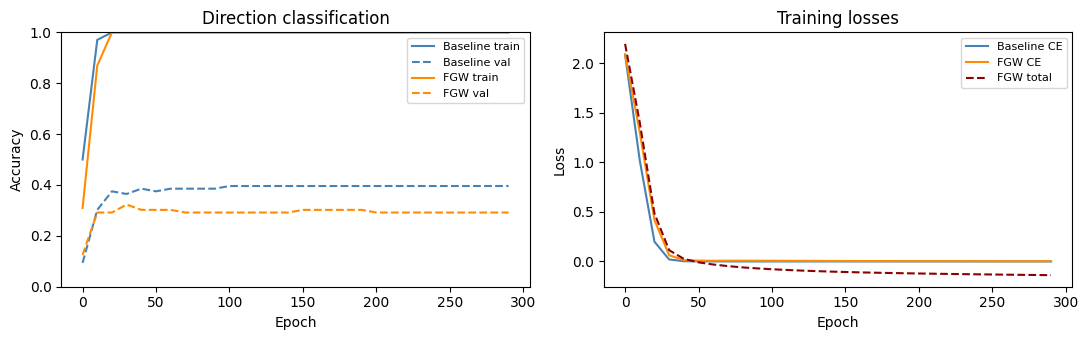

In [76]:
# Learning curves
epochs = np.arange(0, 300, 10)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

ax = axes[0]
ax.plot(epochs, log_base['acc_tr'], color='steelblue',  ls='-',  label='Baseline train')
ax.plot(epochs, log_base['acc_va'], color='steelblue',  ls='--', label='Baseline val')
ax.plot(epochs, log_fgw['acc_tr'],  color='darkorange', ls='-',  label='FGW train')
ax.plot(epochs, log_fgw['acc_va'],  color='darkorange', ls='--', label='FGW val')
ax.set(xlabel='Epoch', ylabel='Accuracy', title='Direction classification', ylim=(0, 1))
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(epochs, log_base['ce'],    color='steelblue',  label='Baseline CE')
ax.plot(epochs, log_fgw['ce'],     color='darkorange', label='FGW CE')
ax.plot(epochs, log_fgw['total'],  color='darkred', ls='--', label='FGW total')
ax.set(xlabel='Epoch', ylabel='Loss', title='Training losses')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Evaluation

### 9a. Extract layer activations on bio stimuli

In [77]:
def get_layer_activations(model, X_bio):
    """Return (h_ret_np, h_v1_np, C_ret, C_v1, tuning_ret, tuning_v1)."""
    model.eval()
    with torch.no_grad():
        h_ret, h_v1 = model.get_layers(X_bio)  # (S*D, N_xxx)
    h_ret_np = h_ret.numpy().T   # (N_ret, S*D)
    h_v1_np  = h_v1.numpy().T   # (N_v1,  S*D)

    def _targets(h, n_stim=N_STIM_BIO, n_dir=N_DIR):
        N = h.shape[0]
        norms = np.linalg.norm(h, axis=1, keepdims=True) + 1e-8
        C = normalize_distance_matrix(
            np.clip(1 - (h / norms) @ (h / norms).T, 0, None)).astype(np.float32)
        np.fill_diagonal(C, 0)
        tuning = h.reshape(N, n_stim, n_dir).mean(axis=1)  # (N, D)
        tuning = np.clip(tuning, 0, None)
        tuning /= (tuning.sum(axis=1, keepdims=True) + 1e-8)
        # OSI / DSI from activations
        tensorX = h.reshape(N, n_stim, n_dir)   # (N, S, D) — T=1 implicit
        osi, _  = compute_osi_and_pref_stim(tensorX, n_stim=n_stim, n_dir=n_dir)
        dsi     = compute_dsi(tensorX, n_stim=n_stim, n_dir=n_dir)
        return C, tuning.astype(np.float32), osi, dsi

    C_ret, t_ret, osi_ret, dsi_ret = _targets(h_ret_np)
    C_v1,  t_v1,  osi_v1,  dsi_v1  = _targets(h_v1_np)
    return h_ret_np, h_v1_np, C_ret, C_v1, t_ret, t_v1, osi_ret, dsi_ret, osi_v1, dsi_v1


(h_ret_base, h_v1_base, C_ret_base, C_v1_base,
 t_ret_base, t_v1_base, osi_ret_base, dsi_ret_base, osi_v1_base, dsi_v1_base) = get_layer_activations(baseline, X_bio)

(h_ret_fgw, h_v1_fgw, C_ret_fgw, C_v1_fgw,
 t_ret_fgw,  t_v1_fgw,  osi_ret_fgw,  dsi_ret_fgw,  osi_v1_fgw,  dsi_v1_fgw)  = get_layer_activations(fgw_model, X_bio)

print('Layer activations extracted.')

Layer activations extracted.


### 9b. RSA — stimulus-space representational similarity

In [78]:
def compute_model_rdm(h_np, n_stim=N_STIM_BIO, n_dir=N_DIR):
    """(S*D, S*D) RDM from model activations (N, S*D) → transpose for conditions."""
    patterns = h_np.T   # (S*D, N) — population patterns per condition
    return squareform(pdist(patterns, metric='euclidean')).astype(np.float32)


def rsa(model_rdm, bio_rdm):
    idx = np.triu_indices(len(model_rdm), k=1)
    rho, _ = spearmanr(model_rdm[idx], bio_rdm[idx])
    return float(rho)


RDM_ret_base = compute_model_rdm(h_ret_base)
RDM_v1_base  = compute_model_rdm(h_v1_base)
RDM_ret_fgw  = compute_model_rdm(h_ret_fgw)
RDM_v1_fgw   = compute_model_rdm(h_v1_fgw)

rsa_ret_base = rsa(RDM_ret_base, RDM_retina)
rsa_v1_base  = rsa(RDM_v1_base,  RDM_v1)
rsa_ret_fgw  = rsa(RDM_ret_fgw,  RDM_retina)
rsa_v1_fgw   = rsa(RDM_v1_fgw,   RDM_v1)

print('RSA (Spearman ρ between model and biological RDMs):')
print(f'  Retina layer — Baseline: {rsa_ret_base:+.3f} | FGW: {rsa_ret_fgw:+.3f}')
print(f'  V1 layer     — Baseline: {rsa_v1_base:+.3f}  | FGW: {rsa_v1_fgw:+.3f}')

RSA (Spearman ρ between model and biological RDMs):
  Retina layer — Baseline: +0.054 | FGW: +0.093
  V1 layer     — Baseline: +0.264  | FGW: +0.180


### 9c. FGW distance to biological targets

In [79]:
def eval_fgw_distance(h_np, y_np, C_bio_np, tuning_bio_np, alpha=0.5):
    """Compute the exact FGW distance between model layer and biological manifold."""
    N_s = h_np.shape[0]
    N_b = C_bio_np.shape[0]
    norms = np.linalg.norm(h_np, axis=1, keepdims=True) + 1e-8
    C_s   = np.clip(1 - (h_np / norms) @ (h_np / norms).T, 0, None).astype(np.float64)

    tuning_s = np.zeros((N_s, N_ORI), dtype=np.float32)
    for k in range(N_ORI):
        mask = (y_np == k)
        if mask.sum() > 0:
            tuning_s[:, k] = np.clip(h_np[:, mask].mean(axis=1), 0, None)
    row_sum = tuning_s.sum(axis=1, keepdims=True) + 1e-8
    tuning_s /= row_sum

    M = cdist(tuning_s, tuning_bio_np, 'euclidean').astype(np.float64)
    if M.max() > 0:
        M /= M.max()

    p = np.ones(N_s, dtype=np.float64) / N_s
    q = np.ones(N_b, dtype=np.float64) / N_b

    _, log_fgw_ = ot.gromov.fused_gromov_wasserstein(
        M, C_s, C_bio_np.astype(np.float64), p, q,
        loss_fun='square_loss', alpha=alpha, max_iter=200, log=True,
    )
    return log_fgw_['fgw_dist']


print('Computing FGW distances (may take ~1 min due to large biological population sizes)...')
fgw_ret_base = eval_fgw_distance(h_ret_base, y_bio_np, C_retina, tuning_retina)
fgw_v1_base  = eval_fgw_distance(h_v1_base,  y_bio_np, C_v1,     tuning_v1)
fgw_ret_fgw  = eval_fgw_distance(h_ret_fgw,  y_bio_np, C_retina, tuning_retina)
fgw_v1_fgw   = eval_fgw_distance(h_v1_fgw,   y_bio_np, C_v1,     tuning_v1)

print(f'FGW(retina layer → bio retina): Baseline={fgw_ret_base:.4f}, FGW model={fgw_ret_fgw:.4f}')
print(f'FGW(V1 layer     → bio V1):     Baseline={fgw_v1_base:.4f},  FGW model={fgw_v1_fgw:.4f}')

Computing FGW distances (may take ~1 min due to large biological population sizes)...
FGW(retina layer → bio retina): Baseline=0.2525, FGW model=0.0477
FGW(V1 layer     → bio V1):     Baseline=0.1760,  FGW model=0.0390


### 9d. Summary bar charts

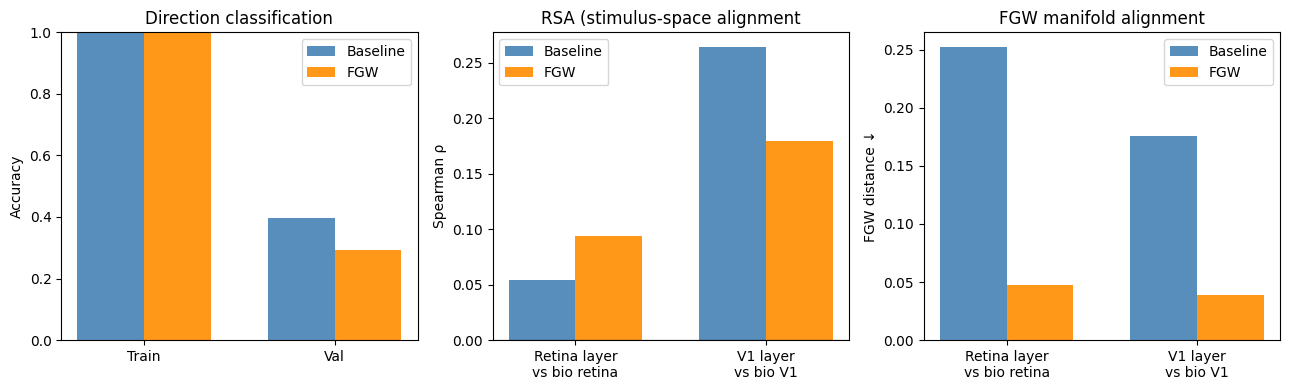

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
x = np.arange(2)
w = 0.35

# Accuracy
ax = axes[0]
ax.bar(x - w/2, [log_base['acc_tr'][-1], log_base['acc_va'][-1]], w,
       label='Baseline', color='steelblue',  alpha=0.9)
ax.bar(x + w/2, [log_fgw['acc_tr'][-1],  log_fgw['acc_va'][-1]],  w,
       label='FGW',      color='darkorange', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(['Train', 'Val'])
ax.set(ylabel='Accuracy', title='Direction classification', ylim=(0, 1))
ax.legend()

# RSA
ax = axes[1]
ax.bar(x - w/2, [rsa_ret_base, rsa_v1_base], w, label='Baseline', color='steelblue',  alpha=0.9)
ax.bar(x + w/2, [rsa_ret_fgw,  rsa_v1_fgw],  w, label='FGW',     color='darkorange', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(['Retina layer\nvs bio retina', 'V1 layer\nvs bio V1'])
ax.set(ylabel='Spearman ρ', title='RSA (stimulus-space alignment')
ax.axhline(0, color='k', lw=0.8); ax.legend()

# FGW distance
ax = axes[2]
ax.bar(x - w/2, [fgw_ret_base, fgw_v1_base], w, label='Baseline', color='steelblue',  alpha=0.9)
ax.bar(x + w/2, [fgw_ret_fgw,  fgw_v1_fgw],  w, label='FGW',     color='darkorange', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(['Retina layer\nvs bio retina', 'V1 layer\nvs bio V1'])
ax.set(ylabel='FGW distance ↓', title='FGW manifold alignment')
ax.legend()

plt.tight_layout()
plt.show()

### 9e. MDS embeddings — neuron space and stimulus space

/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` 

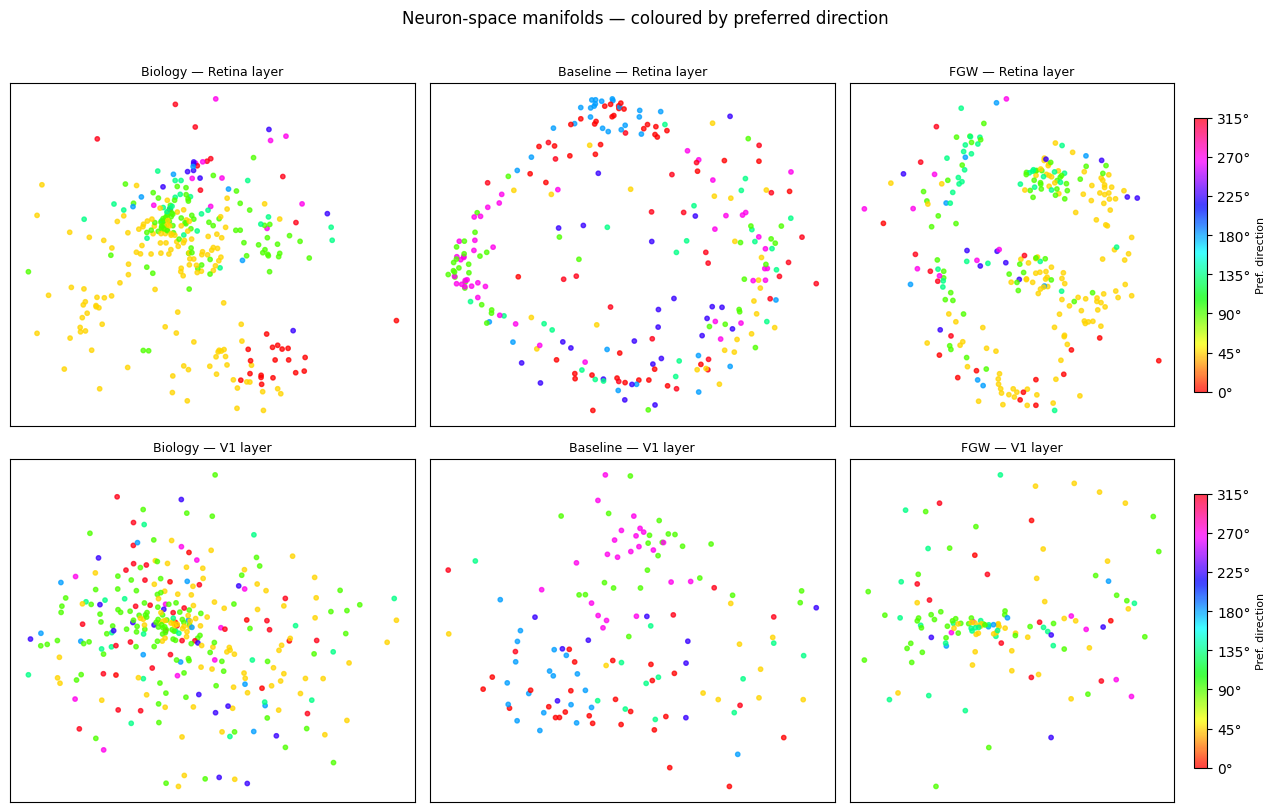

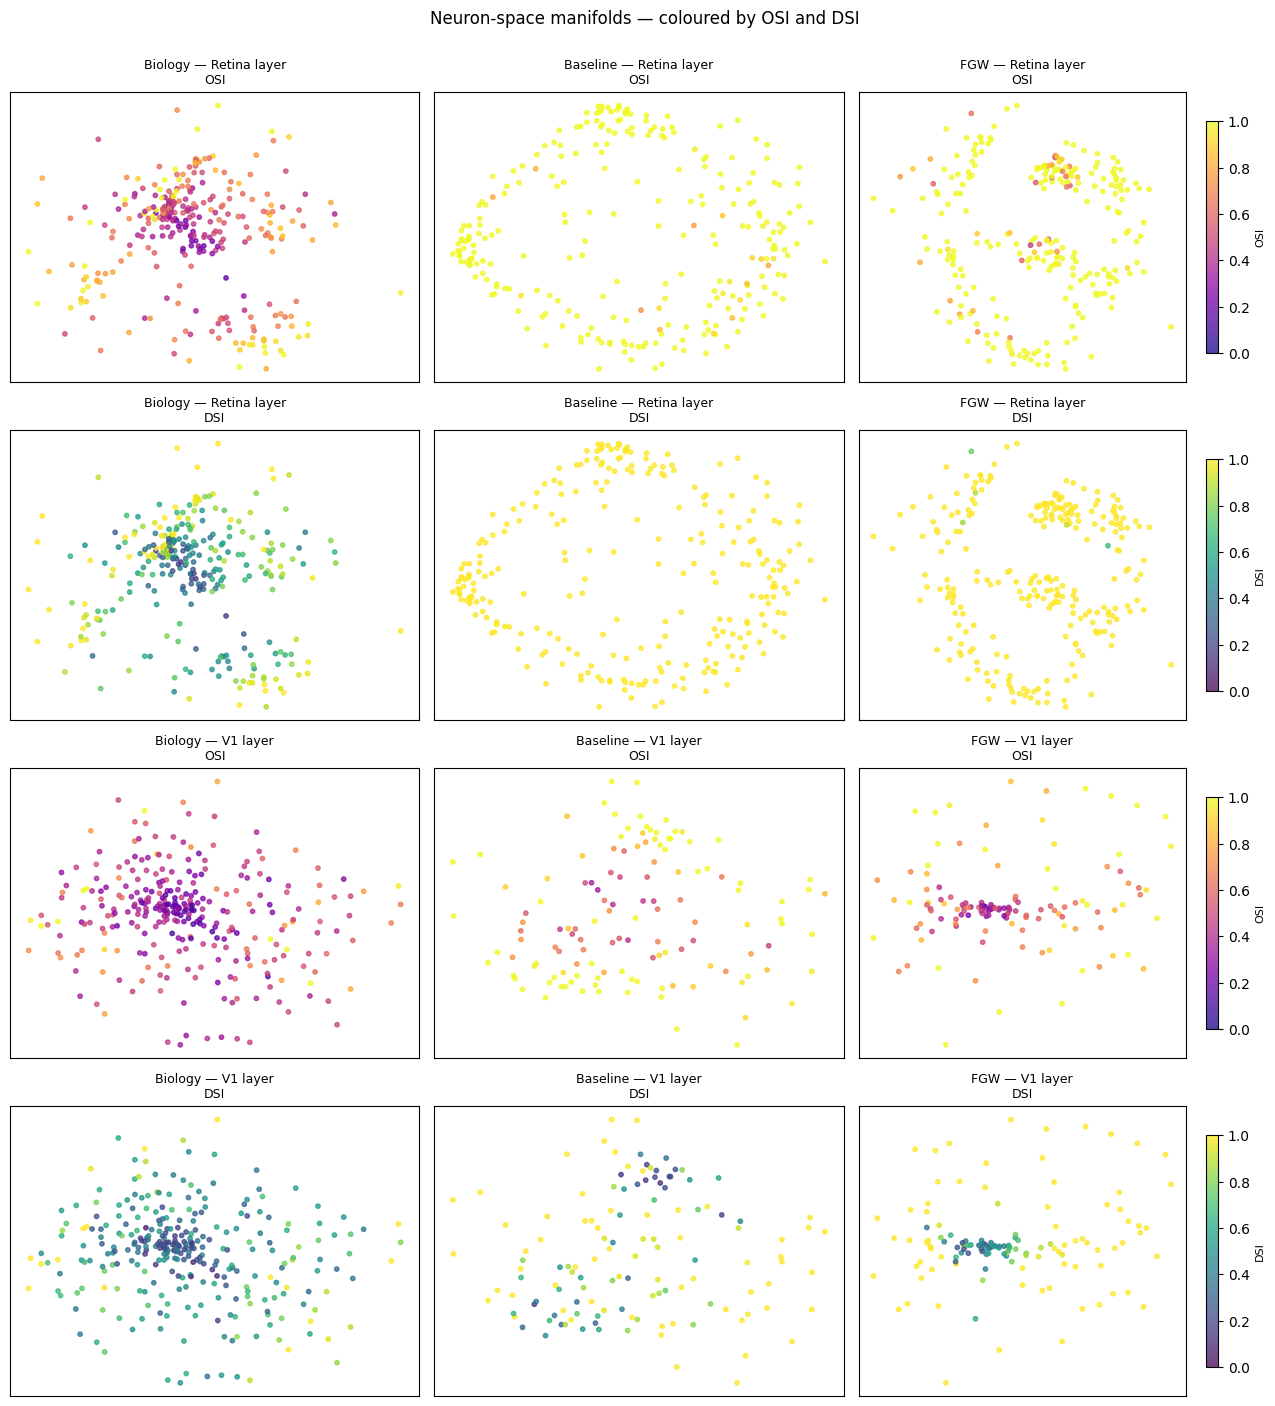

In [81]:
DIR_COLORS  = plt.cm.hsv(np.linspace(0, 1, N_DIR + 1)[:-1])
STIM_COLORS = np.tile(DIR_COLORS, (N_STIM_BIO, 1))   # direction colours repeated per stim cat


def mds_embed(C, seed=SEED):
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=seed, n_init=4)
    return mds.fit_transform(C)


# Subsample biological neurons (MDS scales as O(N^3))
rng = np.random.default_rng(SEED)
sub_ret = rng.choice(len(C_retina), min(300, len(C_retina)), replace=False)
sub_v1  = rng.choice(len(C_v1),     min(300, len(C_v1)),     replace=False)

# Pre-compute all MDS embeddings once (reused across coloring figures)
embs = {
    'bio_ret':  mds_embed(C_retina[np.ix_(sub_ret, sub_ret)]),
    'base_ret': mds_embed(C_ret_base),
    'fgw_ret':  mds_embed(C_ret_fgw),
    'bio_v1':   mds_embed(C_v1[np.ix_(sub_v1, sub_v1)]),
    'base_v1':  mds_embed(C_v1_base),
    'fgw_v1':   mds_embed(C_v1_fgw),
}

# Per-neuron FGW features for coloring:
#   index 0 = preferred direction (argmax of direction tuning)
#   index 1 = OSI
#   index 2 = DSI
feats = {
    'bio_ret':  (tuning_retina[sub_ret].argmax(1), osi_retina[sub_ret],  dsi_retina[sub_ret]),
    'base_ret': (t_ret_base.argmax(1),              osi_ret_base,          dsi_ret_base),
    'fgw_ret':  (t_ret_fgw.argmax(1),               osi_ret_fgw,           dsi_ret_fgw),
    'bio_v1':   (tuning_v1[sub_v1].argmax(1),        osi_v1[sub_v1],        dsi_v1[sub_v1]),
    'base_v1':  (t_v1_base.argmax(1),               osi_v1_base,           dsi_v1_base),
    'fgw_v1':   (t_v1_fgw.argmax(1),                osi_v1_fgw,            dsi_v1_fgw),
}

COL_TITLES = ['Biology', 'Baseline', 'FGW']
ROW_KEYS   = [['bio_ret', 'base_ret', 'fgw_ret'],
              ['bio_v1',  'base_v1',  'fgw_v1']]
ROW_LABELS = ['Retina layer', 'V1 layer']

# ── Figure 1: coloured by preferred direction ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, keys in enumerate(ROW_KEYS):
    for col, key in enumerate(keys):
        ax = axes[row, col]
        sc = ax.scatter(*embs[key].T, c=feats[key][0],
                        cmap='hsv', vmin=0, vmax=N_DIR - 1,
                        s=10, alpha=0.75)
        ax.set_title(f'{COL_TITLES[col]} — {ROW_LABELS[row]}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 2:
            cb = plt.colorbar(sc, ax=ax, shrink=0.8)
            cb.set_ticks(range(N_DIR))
            cb.set_ticklabels([f'{k*45}°' for k in range(N_DIR)])
            cb.set_label('Pref. direction', fontsize=8)

fig.suptitle('Neuron-space manifolds — coloured by preferred direction', y=1.01)
plt.tight_layout()
plt.show()

# ── Figure 2: coloured by OSI and DSI ─────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(13, 14))
feat_specs = [
    ('OSI', 1, 'plasma',  'ret'),
    ('DSI', 2, 'viridis', 'ret'),
    ('OSI', 1, 'plasma',  'v1'),
    ('DSI', 2, 'viridis', 'v1'),
]
for r, (feat_name, feat_idx, cmap, layer) in enumerate(feat_specs):
    keys = [f'bio_{layer}', f'base_{layer}', f'fgw_{layer}']
    layer_label = 'Retina layer' if layer == 'ret' else 'V1 layer'
    for col, key in enumerate(keys):
        ax   = axes[r, col]
        vals = feats[key][feat_idx]
        sc   = ax.scatter(*embs[key].T, c=vals,
                          cmap=cmap, vmin=0, vmax=1,
                          s=10, alpha=0.75)
        ax.set_title(f'{COL_TITLES[col]} — {layer_label}\n{feat_name}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 2:
            cb = plt.colorbar(sc, ax=ax, shrink=0.8)
            cb.set_label(feat_name, fontsize=8)

fig.suptitle('Neuron-space manifolds — coloured by OSI and DSI', y=1.001)
plt.tight_layout()
plt.show()


/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` 

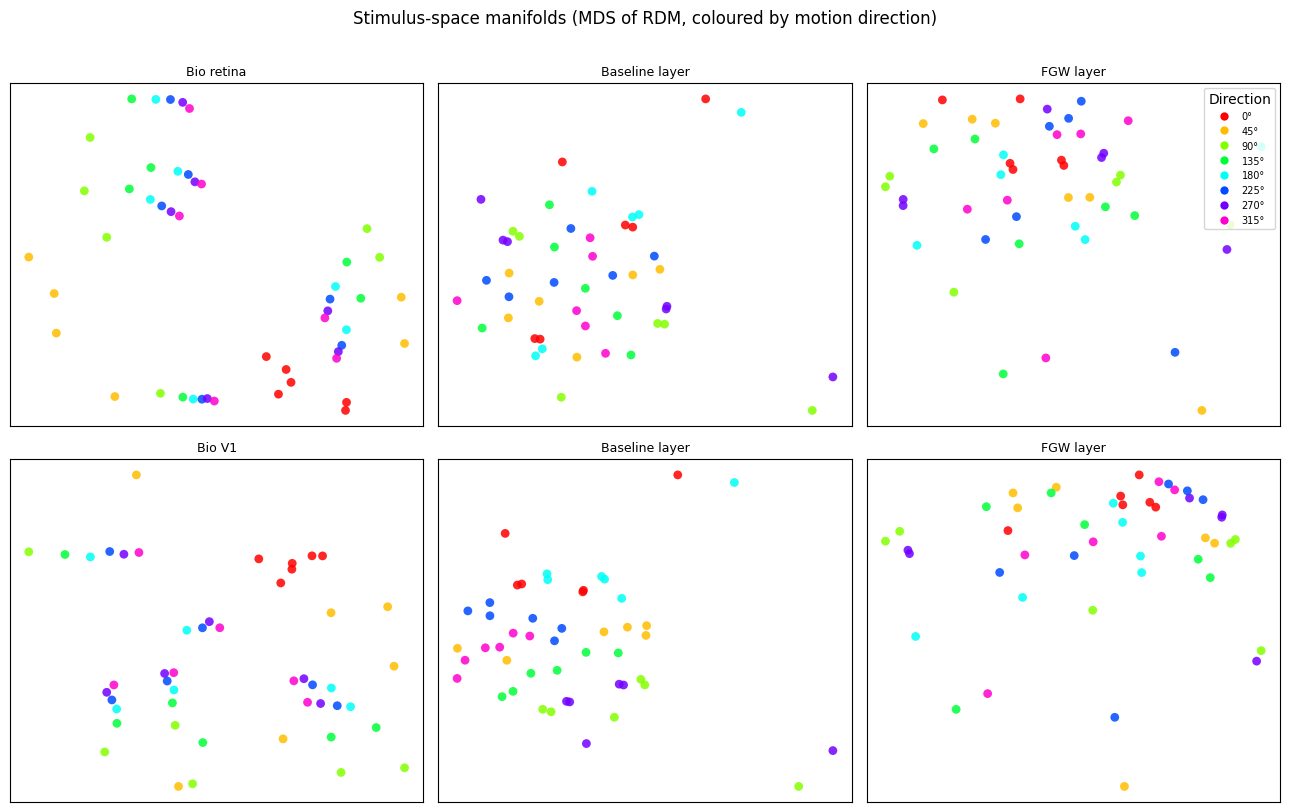

In [82]:
# --- stimulus-space manifolds, coloured by direction ---
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, (RDM_bio, RDM_base, RDM_fgw, bio_name) in enumerate([
    (RDM_retina, RDM_ret_base, RDM_ret_fgw, 'Bio retina'),
    (RDM_v1,     RDM_v1_base,  RDM_v1_fgw,  'Bio V1'),
]):
    for col, (rdm, title) in enumerate(zip(
        [RDM_bio, RDM_base, RDM_fgw],
        [bio_name, 'Baseline layer', 'FGW layer'],
    )):
        ax  = axes[row, col]
        emb = mds_embed(rdm)
        ax.scatter(emb[:, 0], emb[:, 1], c=STIM_COLORS,
                   s=40, alpha=0.85, edgecolors='none')
        ax.set_title(title, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

# Direction legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=DIR_COLORS[k],
                       markersize=7, label=f'{k*45}°') for k in range(N_DIR)]
axes[0, 2].legend(handles=handles, fontsize=7, loc='upper right', title='Direction')

fig.suptitle('Stimulus-space manifolds (MDS of RDM, coloured by motion direction)', y=1.01)
plt.tight_layout()
plt.show()

### 9f. OSI and DSI distributions

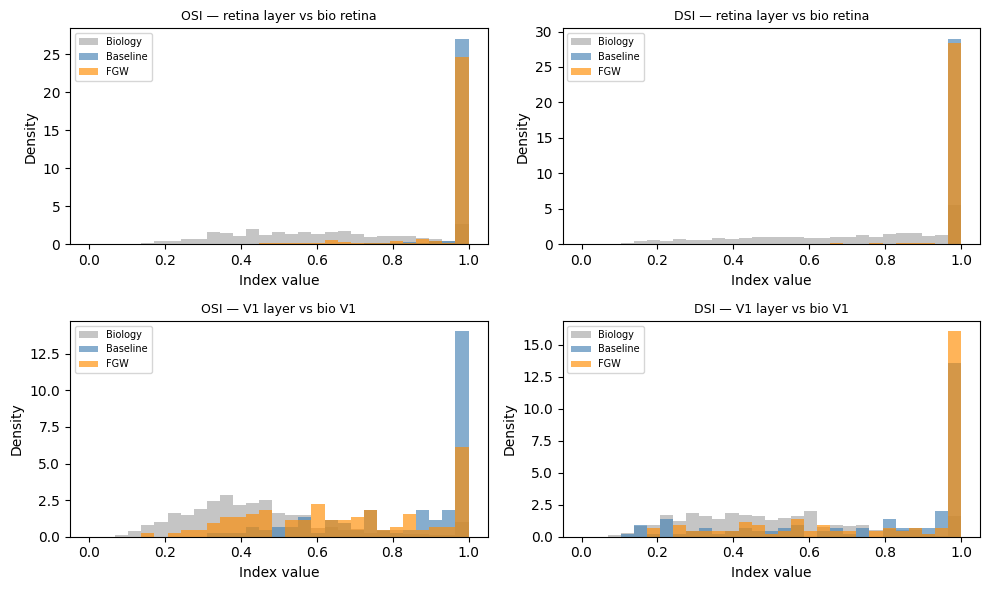

Summary statistics:
  OSI retina    bio=0.609  baseline=0.991  fgw=0.962
  DSI retina    bio=0.688  baseline=1.000  fgw=0.996
  OSI V1        bio=0.442  baseline=0.850  fgw=0.675
  DSI V1        bio=0.499  baseline=0.780  fgw=0.804


In [83]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for ax, (bio_vals, base_vals, fgw_vals, title) in zip(axes.flat, [
    (osi_retina, osi_ret_base, osi_ret_fgw, 'OSI — retina layer vs bio retina'),
    (dsi_retina, dsi_ret_base, dsi_ret_fgw, 'DSI — retina layer vs bio retina'),
    (osi_v1,     osi_v1_base,  osi_v1_fgw,  'OSI — V1 layer vs bio V1'),
    (dsi_v1,     dsi_v1_base,  dsi_v1_fgw,  'DSI — V1 layer vs bio V1'),
]):
    bins = np.linspace(0, 1, 30)
    ax.hist(bio_vals,  bins=bins, density=True, alpha=0.45, color='gray',       label='Biology')
    ax.hist(base_vals, bins=bins, density=True, alpha=0.65, color='steelblue',  label='Baseline')
    ax.hist(fgw_vals,  bins=bins, density=True, alpha=0.65, color='darkorange', label='FGW')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Index value'); ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print('Summary statistics:')
for name, bio, base, fgw_ in [
    ('OSI retina', osi_retina, osi_ret_base, osi_ret_fgw),
    ('DSI retina', dsi_retina, dsi_ret_base, dsi_ret_fgw),
    ('OSI V1',     osi_v1,     osi_v1_base,  osi_v1_fgw),
    ('DSI V1',     dsi_v1,     dsi_v1_base,  dsi_v1_fgw),
]:
    print(f'  {name:12s}  bio={bio.mean():.3f}  baseline={base.mean():.3f}  fgw={fgw_.mean():.3f}')

### 9g. Final summary table

In [84]:
print('=' * 65)
print(f'{"Metric":<35}  {"Baseline":>10}  {"FGW":>10}')
print('-' * 65)
print(f'{"Train accuracy":<35}  {log_base["acc_tr"][-1]:>10.3f}  {log_fgw["acc_tr"][-1]:>10.3f}')
print(f'{"Val accuracy":<35}  {log_base["acc_va"][-1]:>10.3f}  {log_fgw["acc_va"][-1]:>10.3f}')
print(f'{"RSA retina layer":<35}  {rsa_ret_base:>10.3f}  {rsa_ret_fgw:>10.3f}')
print(f'{"RSA V1 layer":<35}  {rsa_v1_base:>10.3f}  {rsa_v1_fgw:>10.3f}')
print(f'{"FGW dist retina layer":<35}  {fgw_ret_base:>10.4f}  {fgw_ret_fgw:>10.4f}')
print(f'{"FGW dist V1 layer":<35}  {fgw_v1_base:>10.4f}  {fgw_v1_fgw:>10.4f}')
print('=' * 65)

Metric                                 Baseline         FGW
-----------------------------------------------------------------
Train accuracy                            1.000       1.000
Val accuracy                              0.396       0.292
RSA retina layer                          0.054       0.093
RSA V1 layer                              0.264       0.180
FGW dist retina layer                    0.2525      0.0477
FGW dist V1 layer                        0.1760      0.0390


In [85]:

import numpy as np
import os

flyvis_tensor_files = [
    "/Users/johannesbertram/repos/FNN_Manifolds/data/sampled/tensor4d_flyvis_Retina_i3_n400_model000.npy",
    "/Users/johannesbertram/repos/FNN_Manifolds/data/sampled/tensor4d_flyvis_T_Tm_i3_n1700_model000.npy",
    "/Users/johannesbertram/repos/FNN_Manifolds/data/sampled/tensor4d_flyvis_Lamina_i3_n350_model000.npy",
    "/Users/johannesbertram/repos/FNN_Manifolds/data/sampled/tensor4d_flyvis_Medulla_i3_n550_model000.npy",
]

print("FlyVis tensor4d shapes:")
print("=" * 70)
for filepath in flyvis_tensor_files:
    if os.path.exists(filepath):
        data = np.load(filepath)
        layer_name = filepath.split("tensor4d_flyvis_")[1].split("_i3")[0]
        print(f"{layer_name:15s}: {data.shape}")


FlyVis tensor4d shapes:
Retina         : (400, 11, 8, 37)
T_Tm           : (1700, 11, 8, 37)
Lamina         : (350, 11, 8, 37)
Medulla        : (550, 11, 8, 37)


In [86]:

# Let's understand the exact output format of createFlowDataset
# Looking at the code from plot_utils.py:
# The function returns a dict mapping inst_i -> array with shape (NDIRS * frames_per_stim, H*W)

# From notebook 02_sample_flyvis.ipynb:
# Example with:
# - categories = 11
# - NDIRS = 8 (directions)
# - frames_per_stim = 37
# - input_shape = (48, 48) -> raveled to 2304 pixels

# In the notebook:
# flow_datasets[0].shape = (11*8*37, 48*48) = (3256, 2304)
# This gets reshaped to:
# sequences = flow_datasets[0].reshape(-1, frames_per_stim, input_shape[0], input_shape[1])
# sequences.shape = (11*8, 37, 48, 48) = (88, 37, 48, 48)

# The array is ordered as:
# [cat0_dir0_frame0, cat0_dir0_frame1, ..., cat0_dir0_frameN, 
#  cat0_dir1_frame0, ..., 
#  cat0_dir7_frameN,
#  cat1_dir0_frame0, ...]

# So indexing:
# stim_arrays[di * frames_per_stim + fii] = frame for direction di and frame index fii within a stimulus
# where di ranges 0 to NDIRS-1 and fii ranges 0 to frames_per_stim-1

print("createFlowDataset Output Format Analysis")
print("=" * 70)
print()
print("Return type: Dictionary")
print("Key: instance index (0 to N_INSTANCES-1)")
print("Value: numpy array with shape (N_TOTAL_FRAMES, H*W)")
print()
print("Example configuration:")
print("  - N_STIM = 11 categories")
print("  - NDIRS = 8 directions")
print("  - frames_per_stim = 37 frames per stimulus")
print("  - input_shape = (48, 48) -> 2304 pixels when raveled")
print()
print("Array shape: (11*8*37, 48*48) = (3256, 2304)")
print()
print("Indexing formula:")
print("  flow_datasets[inst_i][cat_idx*NDIRS*frames_per_stim + dir_idx*frames_per_stim + frame_idx]")
print("    = flat array of shape (2304,) with pixel values for that frame")
print()
print("Reshape to view frames:")
print("  sequences = flow_datasets[inst_i].reshape(-1, frames_per_stim, H, W)")
print("  sequences.shape = (N_STIM * NDIRS, frames_per_stim, 48, 48)")
print()
print("Frame ordering within each stimulus category:")
print("  Outer loop: directions (0-7)")
print("  Inner loop: time frames (0-36)")
print("  So stim_arrays[di * frames_per_stim + fii] is frame fii of direction di")


createFlowDataset Output Format Analysis

Return type: Dictionary
Key: instance index (0 to N_INSTANCES-1)
Value: numpy array with shape (N_TOTAL_FRAMES, H*W)

Example configuration:
  - N_STIM = 11 categories
  - NDIRS = 8 directions
  - frames_per_stim = 37 frames per stimulus
  - input_shape = (48, 48) -> 2304 pixels when raveled

Array shape: (11*8*37, 48*48) = (3256, 2304)

Indexing formula:
  flow_datasets[inst_i][cat_idx*NDIRS*frames_per_stim + dir_idx*frames_per_stim + frame_idx]
    = flat array of shape (2304,) with pixel values for that frame

Reshape to view frames:
  sequences = flow_datasets[inst_i].reshape(-1, frames_per_stim, H, W)
  sequences.shape = (N_STIM * NDIRS, frames_per_stim, 48, 48)

Frame ordering within each stimulus category:
  Outer loop: directions (0-7)
  Inner loop: time frames (0-36)
  So stim_arrays[di * frames_per_stim + fii] is frame fii of direction di
